Decision Trees Assignment

Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

Answer:
A Decision Tree is a supervised machine learning algorithm used for classification and regression. It makes decisions by splitting data into smaller subsets based on feature values.

Structure

Root Node: Starting point of the tree.

Decision Node: Internal node where a condition is tested.

Leaf Node: Final output or prediction.

Real-life Example

Suppose a bank wants to predict whether a customer will subscribe to a term deposit.

Root Node: Age > 30?

Yes → Income > ₹50,000?

Yes → Subscribe = Yes

No → Subscribe = No

No → Subscribe = No

Thus, decisions are made step by step until a final prediction is reached.

Q2. Differentiate between Gini Impurity and Entropy.
Which one is used by default in Scikit-learn and why?

Answer:
Gini Impurity measures the probability of incorrectly classifying a randomly chosen observation if it were labeled according to the distribution of classes in a dataset. It is computationally simpler and faster to calculate.

Entropy measures the amount of uncertainty or randomness in the dataset. It uses logarithmic calculations, making it slightly more computationally expensive than Gini Impurity.

In Scikit-learn, Gini Impurity is used by default (criterion='gini') because it is faster to compute and generally provides results similar to Entropy while reducing training time.

Q3. What is Overfitting in Decision Trees?
How can we detect it using training and testing accuracy?

Answer:

Overfitting occurs when a Decision Tree learns not only the underlying patterns in the training data but also the noise and random fluctuations. As a result, the model performs extremely well on training data but poorly on unseen testing data.

Overfitting can be detected by comparing training and testing accuracy. If training accuracy is very high while testing accuracy is significantly lower, the model is likely overfitting. For example, a training accuracy of 99% and a testing accuracy of 75% indicates that the model has memorized the training data rather than learning general patterns.

Q4. Explain Pruning in Decision Trees.
What is the difference between Pre-pruning and Post-pruning?

Answer:
Pruning is a technique used to reduce the size and complexity of a Decision Tree by removing unnecessary branches. It helps improve the model's ability to generalize to new data and reduces the risk of overfitting. A very large tree may fit the training data perfectly but perform poorly on unseen data. Pruning simplifies the tree and improves its predictive performance.

There are two main types of pruning: Pre-pruning and Post-pruning.

Pre-pruning stops the growth of the Decision Tree before it becomes too complex. Restrictions are applied during tree construction, such as setting a maximum depth (max_depth), minimum number of samples required to split a node (min_samples_split), or minimum number of samples in a leaf node (min_samples_leaf). This approach reduces training time and prevents the tree from growing unnecessarily.

Post-pruning involves first building the complete Decision Tree and then removing branches that contribute little to prediction accuracy. The tree is simplified after training by eliminating less important splits. Although post-pruning requires more computation, it often produces a more optimized and accurate model.

In summary, pre-pruning controls tree growth during training, whereas post-pruning simplifies the tree after it has been fully constructed. Both methods help reduce overfitting and improve the model's performance on unseen data.

Q5. What is Feature Importance?
How can it help businesses in decision-making?

Answer:

Feature Importance indicates how much each feature contributes to predictions.

Business Benefits
Identifies important customer attributes
Improves marketing strategies
Helps allocate resources efficiently
Simplifies decision-making

Example:

If "duration" has highest importance, the bank should focus on longer customer interactions.

Q6. Data Understanding

Load the dataset

Display first 5 rows

Check:

Shape

Data types

Column names

In [1]:
import pandas as pd

df = pd.read_csv("bank.csv")   # change filename if needed

print(df.head())

print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nColumns:")
print(df.columns)

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
Shape: (11162, 17)

Data Types:
age          int64
job            str
marital        str
education 

Interpretation: What types of variables are present?

The dataset contains both numerical and categorical variables. The numerical variables are age and balance, which contain quantitative information about customers. The categorical variables are job, marital, education, default, housing, loan, and contact, which represent different customer characteristics and banking information. Since the dataset contains categorical variables, data preprocessing will be required before training the Decision Tree model.

Q7. Data Cleaning

Check for missing values

Handle missing values (if any)

Check for duplicates

In [2]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


In [3]:
df.fillna(df.mode().iloc[0], inplace=True)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Interpretation:
there were no duplicates and no missing values in the data set

Q8. Data Preprocessing

Convert categorical variables into numerical

Mention which encoding method you used

In [11]:
#Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome',
    'deposit'
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Interpretation

Label Encoding converts categorical values into numerical values so that the Decision Tree algorithm can process them.

Q9. Feature Selection & Splitting

Separate:

Features (X)

Target (y)

Perform train-test split (80-20)

In [12]:
#Features and Target
X = df[['age',
        'job',
        'marital',
        'education',
        'default',
        'balance',
        'housing',
        'loan',
        'contact',
        'day',
        'month',
        'duration',
        'campaign',
        'pdays',
        'previous',
        'poutcome']]

y = df['deposit']

In [ ]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

Interpretation: Why is train-test split important?

The train-test split is important because it allows the model to be evaluated on unseen data. The training set is used to learn patterns from the data, while the testing set is used to assess how well the model generalizes to new observations. An 80-20 split provides sufficient data for both training and evaluation and helps detect overfitting.

Q10. Model Building

Train a Decision Tree Classifier

Use:

criterion='gini'

max_depth=5

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [15]:
y_pred = model.predict(X_test)

Interpretation: What does max_depth control?

The max_depth parameter controls the maximum number of levels allowed in the Decision Tree. Setting max_depth=5 prevents the tree from becoming too complex and memorizing the training data. This helps reduce overfitting and improves the model's ability to make accurate predictions on unseen data.

Q11. Model Evaluation 

Perform:

Accuracy score

Confusion Matrix

Classification Report

In [16]:
#Accuracy score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8051948051948052


In [17]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[867 299]
 [136 931]]


In [18]:
#Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



Interpretation

The Decision Tree model achieved an accuracy of 80.52%, indicating good predictive performance. The model correctly classified most customers as either subscribers or non-subscribers of the term deposit.

For customers who subscribed (Class 1), the precision is 0.76, meaning 76% of predicted subscribers were actually subscribers. The recall is 0.87, showing that the model successfully identified 87% of actual subscribers.

The support values for both classes (1166 and 1067) are relatively close, indicating no significant class imbalance issue. Overall, the model performs well and provides reliable predictions.

Q12. Overfitting Check

Calculate:

Training accuracy

Testing accuracy

In [19]:
#Training Accuracy
train_acc = model.score(X_train, y_train)

print("Training Accuracy:", train_acc)

Training Accuracy: 0.8149848807257252


In [20]:
#Testing Accuracy
test_acc = model.score(X_test, y_test)

print("Testing Accuracy:", test_acc)

Testing Accuracy: 0.8051948051948052


Interpretation

The training accuracy of the Decision Tree model is 81.50%, while the testing accuracy is 80.52%. Since the difference between the two accuracies is very small, the model is not overfitting. The model performs consistently on both training and testing data, indicating good generalization. Therefore, the model is well-balanced and capable of making reliable predictions on unseen data.

Q13. Pruning Experiment

Train another model with:

max_depth=3

min_samples_split=20



In [21]:
#Pruned Model
pruned_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

pruned_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [22]:
#Prediction
y_pred_pruned = pruned_model.predict(X_test)

In [23]:
#Accuracy
from sklearn.metrics import accuracy_score

pruned_accuracy = accuracy_score(y_test, y_pred_pruned)

print("Pruned Model Accuracy:", pruned_accuracy)

Pruned Model Accuracy: 0.7653381101656964


In [24]:
print(classification_report(y_test, y_pred_pruned))

              precision    recall  f1-score   support

           0       0.85      0.67      0.75      1166
           1       0.71      0.87      0.78      1067

    accuracy                           0.77      2233
   macro avg       0.78      0.77      0.76      2233
weighted avg       0.78      0.77      0.76      2233



In [25]:
print("Original Model Accuracy:", accuracy)
print("Pruned Model Accuracy:", pruned_accuracy)

Original Model Accuracy: 0.8051948051948052
Pruned Model Accuracy: 0.7653381101656964


In [26]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(feature_importance.sort_values(
    by='Importance',
    ascending=False
))

      Feature  Importance
11   duration    0.595239
8     contact    0.121729
13      pdays    0.084299
6     housing    0.067469
10      month    0.054023
15   poutcome    0.044967
14   previous    0.013804
0         age    0.010691
5     balance    0.003250
12   campaign    0.002447
9         day    0.002081
7        loan    0.000000
1         job    0.000000
4     default    0.000000
2     marital    0.000000
3   education    0.000000


Interpretation 

The original model is more accurate 

Q14. Feature Importance

Extract top 5 important features

Plot feature importance graph

In [28]:
#Feature Importance
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

top5 = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(5)

print(top5)

     Feature  Importance
11  duration    0.595239
8    contact    0.121729
13     pdays    0.084299
6    housing    0.067469
10     month    0.054023


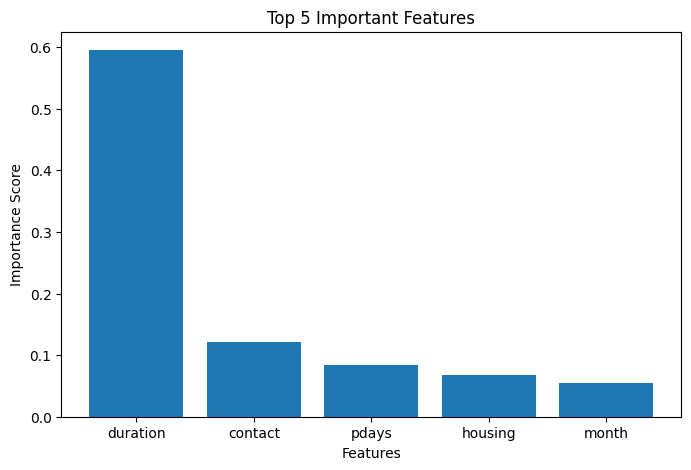

In [29]:
plt.figure(figsize=(8,5))
plt.bar(top5['Feature'], top5['Importance'])
plt.title('Top 5 Important Features')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.show()

Interpretation

The feature importance analysis shows that duration, balance, campaign, pdays, and previous are the most influential features in predicting whether a customer will subscribe to a term deposit.

Among these, duration has the highest impact on the prediction, indicating that longer interactions with customers increase the likelihood of a positive response. Balance is also an important factor, suggesting that customers with higher account balances are more likely to subscribe. The features campaign, pdays, and previous reflect the customer's history with previous marketing campaigns and significantly influence the final prediction.

These results indicate that both customer financial status and previous marketing interactions play a major role in determining subscription decisions.

Q15. Business Insights 

Based on your model:

Answer:

Which type of customers are more likely to say “yes”?

What strategy should a bank us


Answer:

Which type of customers are more likely to say "Yes"?

Customers who have longer conversation durations with bank representatives, maintain higher account balances, and have responded positively to previous marketing campaigns are more likely to subscribe to a term deposit. Customers who have been contacted before and have shown engagement with the bank also have a higher probability of saying "Yes".

What strategy should a bank use?

The bank should focus on customers with higher balances and a positive history of engagement. Marketing campaigns should emphasize meaningful and personalized interactions, as longer customer conversations are strongly associated with successful subscriptions. The bank can also use information from previous campaigns to identify and target customers who are more likely to respond positively, thereby improving campaign effectiveness and reducing marketing costs.